Import Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Load Dataset

In [2]:
df = pd.read_csv("student-mat.csv", sep=";")

Display First Rows

In [3]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


Dataset Information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

Shape

In [5]:
print(df.shape)

(395, 33)


Check For Missing Values

In [6]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Encode Categorical Variables

In [7]:
# One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)
# Checking Shape
print(df.shape)

(395, 42)


Selecting Features 

In [8]:
X = df.drop("G3", axis=1)

y = df["G3"]

Train - Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Feature Scaling

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Convert to NumPy Arrays

In [11]:
X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

Implemeting Gradient Descent 

In [12]:
class LinearRegressionGD:

    def __init__(self,
                 learning_rate=0.01,
                 iterations=1000):

        self.learning_rate = learning_rate
        self.iterations = iterations

    def fit(self, X, y):

        self.m = X.shape[0]
        self.n = X.shape[1]

        self.weights = np.zeros(self.n)

        self.bias = 0

        self.loss_history = []

        for i in range(self.iterations):

            y_pred = np.dot(X, self.weights) + self.bias

            dw = (1/self.m) * np.dot(X.T, (y_pred-y))

            db = (1/self.m) * np.sum(y_pred-y)

            self.weights -= self.learning_rate * dw

            self.bias -= self.learning_rate * db

            loss = (1/(2*self.m))*np.sum((y_pred-y)**2)

            self.loss_history.append(loss)

    def predict(self, X):

        return np.dot(X,self.weights)+self.bias

Train Model

In [13]:
model = LinearRegressionGD(
    learning_rate=0.01,
    iterations=1000
)

model.fit(X_train, y_train)

Prediction

In [14]:
y_pred = model.predict(X_test)

Evaluation Metrices 

In [15]:
# MAE
mae = mean_absolute_error(y_test,y_pred)

In [16]:
# MSE
mse = mean_squared_error(y_test,y_pred)

In [17]:
# RMSE
rmse = np.sqrt(mse)

In [ ]:
# R2
r2 = r2_score(y_test,y_pred)

In [19]:
print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R2 Score :",r2)

MAE : 1.670028943032187
MSE : 5.6936391694756425
RMSE : 2.386134776050096
R2 Score : 0.7223298685908052


Loss Curve

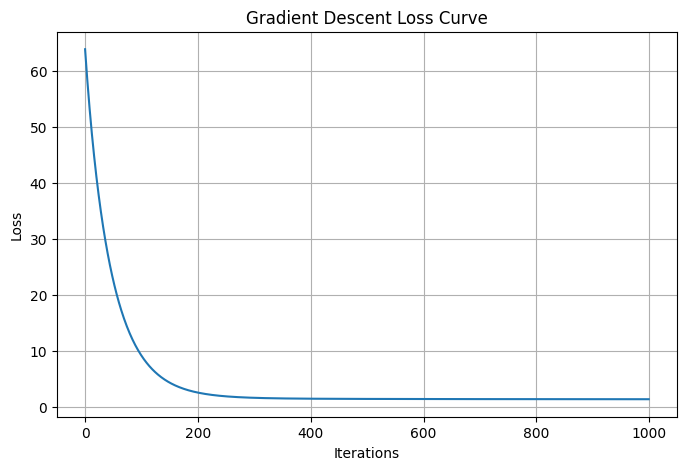

In [20]:
plt.figure(figsize=(8,5))

plt.plot(model.loss_history)

plt.xlabel("Iterations")

plt.ylabel("Loss")

plt.title("Gradient Descent Loss Curve")

plt.grid(True)

plt.show()

Actual vs Predicted 

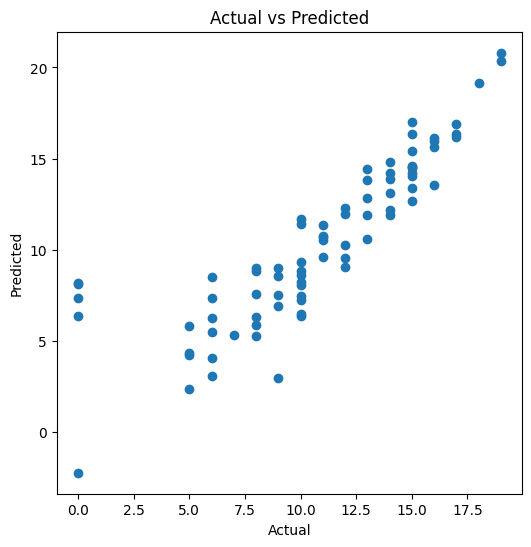

In [21]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

Different Learning Rates 

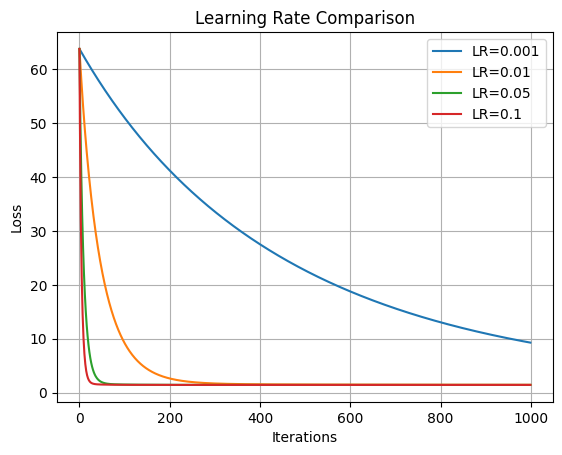

In [23]:
# 1
learning_rates = [0.001,0.01,0.05,0.1]
for lr in learning_rates:

    model = LinearRegressionGD(
        learning_rate=lr,
        iterations=1000
    )

    model.fit(X_train,y_train)

    plt.plot(model.loss_history,label=f"LR={lr}")

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid(True)
plt.show()

1.The Gradient Descent model converged smoothly as the loss decreased steadily and stabilized after several iterations.
2.A moderate learning rate gave the best balance between convergence speed and stability. Overall, the model achieved good prediction performance with low errors and a satisfactory R² score, making it suitable for predicting student performance.